# Protein Folding QUBO Benchmark: 8-Residue (2×4 Lattice)**Problem:** 8 residues, 2×4 lattice, 64 variables**Instances:** 12 diverse sequences**Sweeps:** 1000, 2500, 5000, 10000, 25000, 50000

---## 1. Setup

In [ ]:
!pip install dwave-neal dimod -q
print('✓ Installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 36.6 MB/s eta 0:00:00
✓ Installed


In [ ]:
import numpy as np
import time
import json
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime

from dimod import BinaryQuadraticModel
from neal import SimulatedAnnealingSampler

print("✓ Imports successful")
print(f"Run started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Imports successful
Run started: 2026-01-19 17:52:31


---## 2. Constants

In [ ]:
AMINO_ACIDS = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I',
               'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']
AA_TO_IDX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}

MJ_MATRIX = np.array([
    [-0.20, -0.34, -0.44, -0.42, -0.62, -0.40, -0.42, -0.29, -0.51, -0.73, -0.65, -0.36, -0.64, -0.69, -0.31, -0.34, -0.40, -0.61, -0.53, -0.68],
    [-0.34, -0.15, -0.44, -0.90, -0.55, -0.50, -0.93, -0.40, -0.33, -0.42, -0.45, -0.35, -0.34, -0.41, -0.24, -0.37, -0.32, -0.26, -0.29, -0.37],
    [-0.44, -0.44, -0.28, -0.46, -0.58, -0.44, -0.51, -0.46, -0.54, -0.51, -0.47, -0.46, -0.41, -0.47, -0.34, -0.48, -0.50, -0.36, -0.42, -0.46],
    [-0.42, -0.90, -0.46, -0.19, -0.52, -0.53, -0.49, -0.44, -0.49, -0.42, -0.35, -0.62, -0.33, -0.36, -0.31, -0.48, -0.44, -0.23, -0.30, -0.36],
    [-0.62, -0.55, -0.58, -0.52, -1.54, -0.65, -0.55, -0.54, -0.73, -0.92, -0.88, -0.47, -0.92, -1.01, -0.49, -0.56, -0.61, -0.84, -0.79, -0.91],
    [-0.40, -0.50, -0.44, -0.53, -0.65, -0.29, -0.55, -0.40, -0.49, -0.56, -0.51, -0.46, -0.47, -0.54, -0.31, -0.43, -0.41, -0.39, -0.42, -0.51],
    [-0.42, -0.93, -0.51, -0.49, -0.55, -0.55, -0.22, -0.43, -0.42, -0.44, -0.37, -0.64, -0.35, -0.40, -0.30, -0.47, -0.43, -0.21, -0.27, -0.38],
    [-0.29, -0.40, -0.46, -0.44, -0.54, -0.40, -0.43, -0.14, -0.46, -0.52, -0.46, -0.41, -0.47, -0.51, -0.26, -0.37, -0.39, -0.44, -0.44, -0.47],
    [-0.51, -0.33, -0.54, -0.49, -0.73, -0.49, -0.42, -0.46, -0.34, -0.66, -0.62, -0.35, -0.64, -0.72, -0.37, -0.46, -0.47, -0.62, -0.57, -0.60],
    [-0.73, -0.42, -0.51, -0.42, -0.92, -0.56, -0.44, -0.52, -0.66, -1.00, -0.95, -0.41, -0.96, -1.04, -0.49, -0.52, -0.59, -0.90, -0.83, -0.98],
    [-0.65, -0.45, -0.47, -0.35, -0.88, -0.51, -0.37, -0.46, -0.62, -0.95, -0.91, -0.37, -0.93, -1.01, -0.46, -0.47, -0.53, -0.89, -0.80, -0.93],
    [-0.36, -0.35, -0.46, -0.62, -0.47, -0.46, -0.64, -0.41, -0.35, -0.41, -0.37, -0.18, -0.32, -0.39, -0.23, -0.39, -0.36, -0.19, -0.24, -0.35],
    [-0.64, -0.34, -0.41, -0.33, -0.92, -0.47, -0.35, -0.47, -0.64, -0.96, -0.93, -0.32, -0.89, -0.98, -0.45, -0.47, -0.52, -0.86, -0.78, -0.92],
    [-0.69, -0.41, -0.47, -0.36, -1.01, -0.54, -0.40, -0.51, -0.72, -1.04, -1.01, -0.39, -0.98, -1.10, -0.50, -0.51, -0.57, -0.98, -0.89, -1.02],
    [-0.31, -0.24, -0.34, -0.31, -0.49, -0.31, -0.30, -0.26, -0.37, -0.49, -0.46, -0.23, -0.45, -0.50, -0.16, -0.30, -0.32, -0.42, -0.38, -0.45],
    [-0.34, -0.37, -0.48, -0.48, -0.56, -0.43, -0.47, -0.37, -0.46, -0.52, -0.47, -0.39, -0.47, -0.51, -0.30, -0.33, -0.41, -0.41, -0.41, -0.48],
    [-0.40, -0.32, -0.50, -0.44, -0.61, -0.41, -0.43, -0.39, -0.47, -0.59, -0.53, -0.36, -0.52, -0.57, -0.32, -0.41, -0.38, -0.45, -0.45, -0.55],
    [-0.61, -0.26, -0.36, -0.23, -0.84, -0.39, -0.21, -0.44, -0.62, -0.90, -0.89, -0.19, -0.86, -0.98, -0.42, -0.41, -0.45, -0.86, -0.76, -0.84],
    [-0.53, -0.29, -0.42, -0.30, -0.79, -0.42, -0.27, -0.44, -0.57, -0.83, -0.80, -0.24, -0.78, -0.89, -0.38, -0.41, -0.45, -0.76, -0.69, -0.78],
    [-0.68, -0.37, -0.46, -0.36, -0.91, -0.51, -0.38, -0.47, -0.60, -0.98, -0.93, -0.35, -0.92, -1.02, -0.45, -0.48, -0.55, -0.84, -0.78, -0.96],
])
print(f"MJ Matrix: {MJ_MATRIX.shape}, range: [{MJ_MATRIX.min():.2f}, {MJ_MATRIX.max():.2f}]")

MJ Matrix: (20, 20), range: [-1.54, -0.14]


In [ ]:
def build_2d_lattice(rows, cols):
    n = rows * cols
    adj = np.zeros((n, n), dtype=int)
    for i in range(n):
        r, c = i // cols, i % cols
        if c < cols - 1: adj[i, i+1] = adj[i+1, i] = 1
        if r < rows - 1: adj[i, i+cols] = adj[i+cols, i] = 1
    return adj

def find_hamiltonian_paths(adj, n, max_paths=100000, time_limit=300):
    paths, start_time, completed = [], time.time(), True
    def dfs(current, visited, path):
        nonlocal completed
        if len(paths) >= max_paths or time.time() - start_time > time_limit:
            completed = False; return False
        if len(path) == n:
            paths.append(path.copy()); return True
        for nxt in range(n):
            if nxt not in visited and adj[current, nxt] == 1:
                visited.add(nxt); path.append(nxt)
                if not dfs(nxt, visited, path): path.pop(); visited.remove(nxt); return False
                path.pop(); visited.remove(nxt)
        return True
    for start in range(n):
        if len(paths) >= max_paths or time.time() - start_time > time_limit: completed = False; break
        dfs(start, {start}, [start])
    return paths, completed

def compute_path_energy(path, sequence, adj):
    E = 0.0
    for i in range(len(sequence)):
        for j in range(i + 2, len(sequence)):
            if adj[path[i], path[j]] == 1:
                E += MJ_MATRIX[AA_TO_IDX[sequence[i]], AA_TO_IDX[sequence[j]]]
    return E

def count_contacts(path, sequence, adj):
    return sum(1 for i in range(len(sequence)) for j in range(i+2, len(sequence)) if adj[path[i], path[j]] == 1)

print("✓ Core functions defined")

✓ Core functions defined


In [ ]:
def build_protein_qubo(sequence, adj, lambda1=2.0, lambda2=3.0, lambda3=3.0):
    N, M = len(sequence), adj.shape[0]
    linear, quadratic, offset = defaultdict(float), defaultdict(float), 0.0
    bit_idx = lambda r, p: r * M + p

    for i in range(N):
        for j in range(i + 2, N):
            C_ij = MJ_MATRIX[AA_TO_IDX[sequence[i]], AA_TO_IDX[sequence[j]]]
            for n in range(M):
                for m in range(M):
                    if adj[n, m] == 1:
                        b_i, b_j = bit_idx(i, n), bit_idx(j, m)
                        quadratic[(min(b_i, b_j), max(b_i, b_j))] += C_ij

    for i in range(N):
        for n in range(M): linear[bit_idx(i, n)] += lambda1 * (-1)
        for n in range(M):
            for m in range(n + 1, M): quadratic[(bit_idx(i, n), bit_idx(i, m))] += lambda1 * 2
        offset += lambda1

    for n in range(M):
        for i in range(N):
            for j in range(i + 1, N): quadratic[(bit_idx(i, n), bit_idx(j, n))] += lambda2

    non_adj = 1 - adj - np.eye(M)
    for i in range(N - 1):
        for n in range(M):
            for m in range(M):
                if non_adj[n, m] == 1:
                    b_i, b_j = bit_idx(i, n), bit_idx(i + 1, m)
                    quadratic[(min(b_i, b_j), max(b_i, b_j))] += lambda3
    return dict(linear), dict(quadratic), offset

def validate_solution(sample, sequence, adj, lambda1, lambda2, lambda3):
    N, M = len(sequence), adj.shape[0]
    b = np.zeros((N, M))
    for bit_idx, val in sample.items():
        if val == 1:
            i, n = bit_idx // M, bit_idx % M
            if i < N: b[i, n] = 1

    E1 = int(np.sum((np.sum(b, axis=1) - 1) ** 2))
    E2 = sum(int(np.sum(b[:, n]) * (np.sum(b[:, n]) - 1) / 2) for n in range(M))
    non_adj = 1 - adj - np.eye(M)
    E3 = int(sum(b[i, :] @ non_adj @ b[i+1, :] for i in range(N-1)))

    E_MJ = sum(MJ_MATRIX[AA_TO_IDX[sequence[i]], AA_TO_IDX[sequence[j]]]
               for i in range(N) for j in range(i+2, N) for n in range(M) for m in range(M)
               if b[i, n] == 1 and b[j, m] == 1 and adj[n, m] == 1)

    is_valid = (E1 == 0) and (E2 == 0) and (E3 == 0)
    path = None
    if is_valid:
        path = [next(n for n in range(M) if b[i, n] == 1) for i in range(N)]
    return is_valid, E_MJ + lambda1*E1 + lambda2*E2 + lambda3*E3, {'E_MJ': E_MJ, 'E1': E1, 'E2': E2, 'E3': E3}, path

def run_sa(linear, quadratic, offset, sequence, adj, num_sweeps, num_reads, beta_range, lam, seed=42):
    bqm = BinaryQuadraticModel(linear, quadratic, offset, vartype='BINARY')
    start = time.time()
    result = SimulatedAnnealingSampler().sample(bqm, num_reads=num_reads, num_sweeps=num_sweeps, beta_range=beta_range, seed=seed)
    solve_time = time.time() - start

    valid = []
    for datum in result.data():
        is_valid, E_total, _, path = validate_solution(datum.sample, sequence, adj, *lam)
        if is_valid: valid.append({'E_total': E_total, 'path': path})

    energies = [s['E_total'] for s in valid]
    return {'solve_time': solve_time, 'valid_count': len(valid), 'valid_rate': len(valid)/num_reads*100,
            'best_E': min(energies) if energies else None, 'energies': energies}

print("✓ QUBO functions defined")

✓ QUBO functions defined


---## 3. Configuration

In [ ]:
LATTICE_ROWS, LATTICE_COLS = 2, 4
NUM_POSITIONS = LATTICE_ROWS * LATTICE_COLS
NUM_RESIDUES = 8
NUM_VARIABLES = NUM_RESIDUES * NUM_POSITIONS
adj_matrix = build_2d_lattice(LATTICE_ROWS, LATTICE_COLS)
print(f"Lattice: {LATTICE_ROWS}×{LATTICE_COLS}, Variables: {NUM_VARIABLES}")

Lattice: 2×4, Variables: 64


In [ ]:
SEQUENCES = [
    "CFIKDLWV",
    "ILFVWMCY",
    "CFWVILMY",
    "WFYCMILV",
    "ACDEFGHI",
    "KLMNPQRS",
    "STVWYACF",
    "RKDECFWI",
    "RKDENQST",
    "HHKKRRDD",
    "SSTTNNQQ",
    "GPAGPSAG"
]
print(f"Sequences: {len(SEQUENCES)}")
for i, s in enumerate(SEQUENCES): print(f"  {i+1:2d}. {s}")

Sequences: 12
   1. CFIKDLWV
   2. ILFVWMCY
   3. CFWVILMY
   4. WFYCMILV
   5. ACDEFGHI
   6. KLMNPQRS
   7. STVWYACF
   8. RKDECFWI
   9. RKDENQST
  10. HHKKRRDD
  11. SSTTNNQQ
  12. GPAGPSAG


In [ ]:
SWEEP_CONFIGS = [
    {
        "num_sweeps": 1000,
        "num_reads": 50,
        "beta_range": [
            1.0,
            50.0
        ]
    },
    {
        "num_sweeps": 2500,
        "num_reads": 50,
        "beta_range": [
            1.0,
            50.0
        ]
    },
    {
        "num_sweeps": 5000,
        "num_reads": 100,
        "beta_range": [
            1.0,
            50.0
        ]
    },
    {
        "num_sweeps": 10000,
        "num_reads": 100,
        "beta_range": [
            1.0,
            50.0
        ]
    },
    {
        "num_sweeps": 25000,
        "num_reads": 100,
        "beta_range": [
            1.0,
            50.0
        ]
    },
    {
        "num_sweeps": 50000,
        "num_reads": 100,
        "beta_range": [
            1.0,
            50.0
        ]
    }
]
LAMBDA_CONFIGS = [(1.5, 2.0, 2.0), (2.0, 3.0, 3.0), (3.0, 4.0, 4.0)]
print(f"Experiments: {len(SEQUENCES)} × {len(SWEEP_CONFIGS)} × {len(LAMBDA_CONFIGS)} = {len(SEQUENCES)*len(SWEEP_CONFIGS)*len(LAMBDA_CONFIGS)}")

Experiments: 12 × 6 × 3 = 216


---## 4. Ground Truth

In [ ]:
print("Computing ground truth...")
ground_truths = {}
for seq in SEQUENCES:
    t0 = time.time()
    paths, complete = find_hamiltonian_paths(adj_matrix, NUM_POSITIONS, max_paths=100000, time_limit=60)
    if paths:
        energies = [(compute_path_energy(p, seq, adj_matrix), p) for p in paths]
        energies.sort()
        ground_truths[seq] = {'E_min': energies[0][0], 'num_paths': len(paths), 'complete': complete}
        print(f"{seq[:16]}...: E_min={energies[0][0]:8.4f}, paths={len(paths):,} ({'✓' if complete else 'partial'})")
print("✓ Done")

Computing ground truth...
CFIKDLWV...: E_min= -2.8400, paths=28 (✓)
ILFVWMCY...: E_min= -2.7200, paths=28 (✓)
CFWVILMY...: E_min= -2.7100, paths=28 (✓)
WFYCMILV...: E_min= -2.7200, paths=28 (✓)
ACDEFGHI...: E_min= -2.1900, paths=28 (✓)
KLMNPQRS...: E_min= -1.3100, paths=28 (✓)
STVWYACF...: E_min= -2.3700, paths=28 (✓)
RKDECFWI...: E_min= -2.2700, paths=28 (✓)
RKDENQST...: E_min= -1.9600, paths=28 (✓)
HHKKRRDD...: E_min= -1.8700, paths=28 (✓)
SSTTNNQQ...: E_min= -1.3900, paths=28 (✓)
GPAGPSAG...: E_min= -0.7900, paths=28 (✓)
✓ Done


---## 5. SA Experiments

In [ ]:
print("Running experiments...")
all_results = []
total_start = time.time()

for seq_idx, seq in enumerate(SEQUENCES):
    gt = ground_truths[seq]
    print(f"\n[{seq_idx+1}/{len(SEQUENCES)}] {seq[:20]}... (E_min={gt['E_min']:.4f})")

    for lam in LAMBDA_CONFIGS:
        linear, quadratic, offset = build_protein_qubo(seq, adj_matrix, *lam)
        for cfg in SWEEP_CONFIGS:
            r = run_sa(linear, quadratic, offset, seq, adj_matrix,
                      cfg['num_sweeps'], cfg['num_reads'], tuple(cfg['beta_range']), lam)

            gap = (r['best_E'] - gt['E_min']) if r['best_E'] else None
            found_opt = gap is not None and abs(gap) < 0.001

            all_results.append({
                'sequence': seq, 'E_min': gt['E_min'], 'lambdas': lam,
                'num_sweeps': cfg['num_sweeps'], 'num_reads': cfg['num_reads'],
                'solve_time': r['solve_time'], 'valid_rate': r['valid_rate'],
                'best_E': r['best_E'], 'gap': gap, 'found_optimal': found_opt
            })

            status = "✓" if found_opt else ("~" if r['valid_rate'] > 50 else "✗")
            print(f"  {status} λ={lam}, sweeps={cfg['num_sweeps']:>6}: valid={r['valid_rate']:5.1f}%", end="")
            print(f", gap={gap:+.4f}" if gap else ", no valid")

total_time = time.time() - total_start
print(f"\n{'='*60}\nDone! {total_time/60:.1f} min")

Running experiments...

[1/12] CFIKDLWV... (E_min=-2.8400)
  ✓ λ=(1.5, 2.0, 2.0), sweeps=  1000: valid= 12.0%, no valid
  ✓ λ=(1.5, 2.0, 2.0), sweeps=  2500: valid= 12.0%, no valid
  ✓ λ=(1.5, 2.0, 2.0), sweeps=  5000: valid= 10.0%, no valid
  ✓ λ=(1.5, 2.0, 2.0), sweeps= 10000: valid= 13.0%, no valid
  ✓ λ=(1.5, 2.0, 2.0), sweeps= 25000: valid=  8.0%, no valid
  ✓ λ=(1.5, 2.0, 2.0), sweeps= 50000: valid= 17.0%, no valid
  ✓ λ=(2.0, 3.0, 3.0), sweeps=  1000: valid= 68.0%, no valid
  ✓ λ=(2.0, 3.0, 3.0), sweeps=  2500: valid= 86.0%, no valid
  ✓ λ=(2.0, 3.0, 3.0), sweeps=  5000: valid= 93.0%, no valid
  ✓ λ=(2.0, 3.0, 3.0), sweeps= 10000: valid= 97.0%, no valid
  ✓ λ=(2.0, 3.0, 3.0), sweeps= 25000: valid= 98.0%, no valid
  ✓ λ=(2.0, 3.0, 3.0), sweeps= 50000: valid=100.0%, no valid
  ✓ λ=(3.0, 4.0, 4.0), sweeps=  1000: valid= 92.0%, no valid
  ✓ λ=(3.0, 4.0, 4.0), sweeps=  2500: valid= 96.0%, no valid
  ✓ λ=(3.0, 4.0, 4.0), sweeps=  5000: valid= 98.0%, no valid
  ✓ λ=(3.0, 4.0, 4.0), swe

---## 6. Analysis

In [ ]:
# Aggregate results
config_stats = defaultdict(lambda: {'valid_rates': [], 'found_optimal': [], 'gaps': [], 'times': []})
for r in all_results:
    key = (r['num_sweeps'], r['lambdas'])
    config_stats[key]['valid_rates'].append(r['valid_rate'])
    config_stats[key]['found_optimal'].append(r['found_optimal'])
    config_stats[key]['times'].append(r['solve_time'])
    if r['gap'] is not None: config_stats[key]['gaps'].append(r['gap'])

config_summary = {k: {
    'avg_valid': np.mean(v['valid_rates']), 'std_valid': np.std(v['valid_rates']),
    'pct_optimal': np.mean(v['found_optimal'])*100,
    'avg_gap': np.mean(v['gaps']) if v['gaps'] else None, 'avg_time': np.mean(v['times'])
} for k, v in config_stats.items()}

print("="*90)
print("RESULTS BY CONFIGURATION")
print("="*90)
print(f"{'Sweeps':>8} {'Lambda':>18} {'Valid %':>10} {'±':>6} {'Optimal %':>10} {'Avg Gap':>10} {'Time':>8}")
print("-"*90)
for (sweeps, lam), s in sorted(config_summary.items()):
    gap_str = f"{s['avg_gap']:+.4f}" if s['avg_gap'] else "N/A"
    print(f"{sweeps:>8} {str(lam):>18} {s['avg_valid']:>10.1f} {s['std_valid']:>6.1f} {s['pct_optimal']:>10.1f} {gap_str:>10} {s['avg_time']:>7.2f}s")

# Best configuration
best_key = max(config_summary.keys(), key=lambda k: (config_summary[k]['pct_optimal'], config_summary[k]['avg_valid']))
best = config_summary[best_key]
print(f"\nBest: {best_key[0]} sweeps, λ={best_key[1]} → {best['pct_optimal']:.1f}% optimal, {best['avg_valid']:.1f}% valid")

RESULTS BY CONFIGURATION
  Sweeps             Lambda    Valid %      ±  Optimal %    Avg Gap     Time
------------------------------------------------------------------------------------------
    1000    (1.5, 2.0, 2.0)       46.3   34.9       75.0    +0.0064    0.05s
    1000    (2.0, 3.0, 3.0)       72.5   21.5      100.0        N/A    0.03s
    1000    (3.0, 4.0, 4.0)       85.2   10.2      100.0        N/A    0.03s
    2500    (1.5, 2.0, 2.0)       50.0   38.8       75.0        N/A    0.11s
    2500    (2.0, 3.0, 3.0)       81.2   23.6      100.0        N/A    0.08s
    2500    (3.0, 4.0, 4.0)       95.0    3.3      100.0        N/A    0.07s
    5000    (1.5, 2.0, 2.0)       54.8   41.2       75.0    +0.0050    0.41s
    5000    (2.0, 3.0, 3.0)       85.8   16.5      100.0        N/A    0.31s
    5000    (3.0, 4.0, 4.0)       96.7    3.2      100.0        N/A    0.26s
   10000    (1.5, 2.0, 2.0)       56.3   42.4       75.0        N/A    0.93s
   10000    (2.0, 3.0, 3.0)       89.

---## 7. Visualization

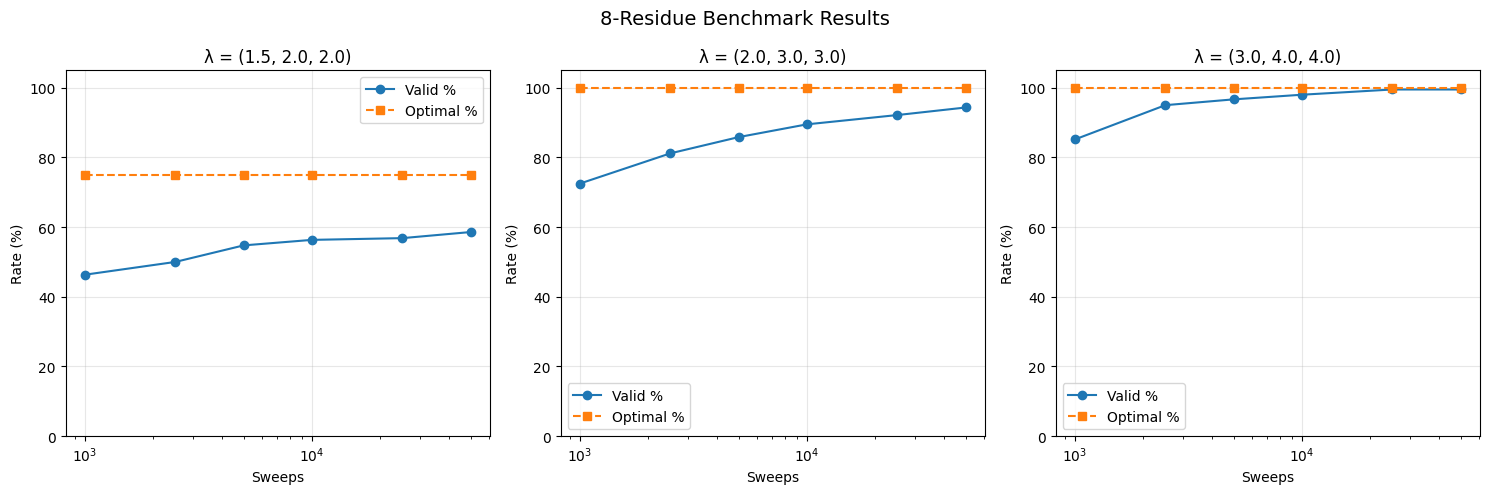

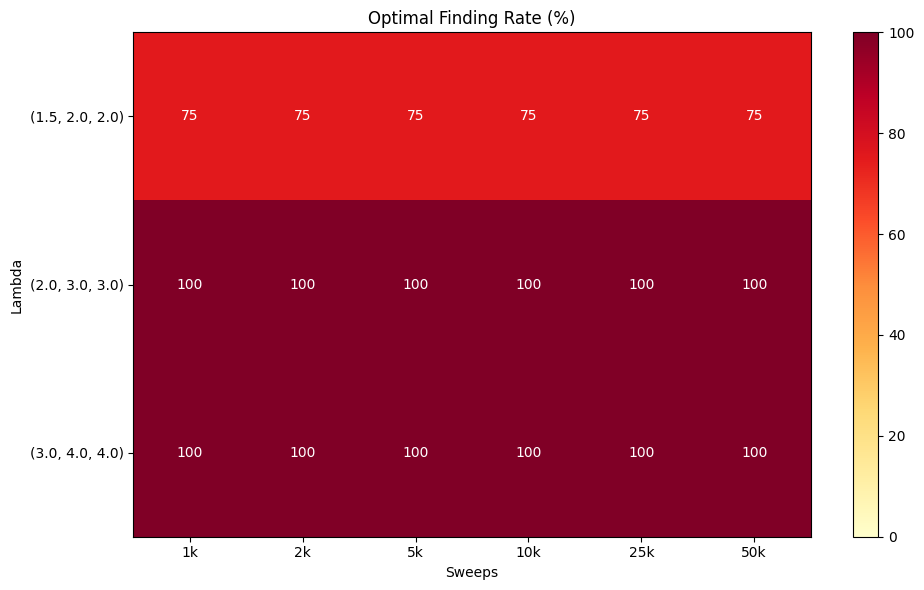

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, lam in zip(axes, LAMBDA_CONFIGS):
    sweeps_list = sorted(set(k[0] for k in config_summary.keys()))
    valid_rates = [config_summary[(s, lam)]['avg_valid'] for s in sweeps_list]
    optimal_rates = [config_summary[(s, lam)]['pct_optimal'] for s in sweeps_list]
    ax.plot(sweeps_list, valid_rates, 'o-', label='Valid %')
    ax.plot(sweeps_list, optimal_rates, 's--', label='Optimal %')
    ax.set_xlabel('Sweeps'); ax.set_ylabel('Rate (%)')
    ax.set_title(f'λ = {lam}'); ax.set_xscale('log'); ax.set_ylim(0, 105); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'{NUM_RESIDUES}-Residue Benchmark Results', fontsize=14)
plt.tight_layout()
plt.show()

# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sweeps_list = sorted(set(k[0] for k in config_summary.keys()))
matrix = np.array([[config_summary[(s, lam)]['pct_optimal'] for s in sweeps_list] for lam in LAMBDA_CONFIGS])
im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)
ax.set_xticks(range(len(sweeps_list))); ax.set_xticklabels([f"{s//1000}k" for s in sweeps_list])
ax.set_yticks(range(len(LAMBDA_CONFIGS))); ax.set_yticklabels([str(l) for l in LAMBDA_CONFIGS])
ax.set_xlabel('Sweeps'); ax.set_ylabel('Lambda'); ax.set_title('Optimal Finding Rate (%)')
for i in range(len(LAMBDA_CONFIGS)):
    for j in range(len(sweeps_list)):
        ax.text(j, i, f"{matrix[i,j]:.0f}", ha='center', va='center', color='white' if matrix[i,j]>50 else 'black')
plt.colorbar(im); plt.tight_layout(); plt.show()

---## 8. Summary

In [ ]:
print("="*70)
print(f"{NUM_RESIDUES}-RESIDUE BENCHMARK SUMMARY")
print("="*70)
print(f"Lattice: {LATTICE_ROWS}×{LATTICE_COLS}, Variables: {NUM_VARIABLES}")
print(f"Instances: {len(SEQUENCES)}, Experiments: {len(all_results)}")
print(f"Runtime: {total_time/60:.1f} min")
print(f"\nBest config: {best_key[0]} sweeps, λ={best_key[1]}")
print(f"  Valid: {best['avg_valid']:.1f}% ± {best['std_valid']:.1f}%")
print(f"  Optimal: {best['pct_optimal']:.1f}%")

8-RESIDUE BENCHMARK SUMMARY
Lattice: 2×4, Variables: 64
Instances: 12, Experiments: 216
Runtime: 3.8 min

Best config: 25000 sweeps, λ=(3.0, 4.0, 4.0)
  Valid: 99.5% ± 0.8%
  Optimal: 100.0%
